# Exercise 8.1
## Sinus forecasting
In this task, we will learn to implement RNNs in Keras.
Therefore:
 - Run the provided script and comment on the output.
 - Vary the number and size of the LSTM layers and compare training time and stability of the performance.

The goal of this task is to predict the next value of a sine function. This is a special case because the output of the network (the `y` value) should correponds to the next input `x` value.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
layers = keras.layers

print(keras.__version__)

3.14.1


### Generation of data
We start by creating a signal trace: `t = 0-100`, `f = sin(pi * t)`

In [3]:
N = 10000
t = np.linspace(0, 100, N)  # time steps
f = np.sin(np.pi * t)  # signal

Split into semi-redundant sub-sequences of `length = window_size + 1` and perform shuffle

In [25]:
window_size = 20
n = N - window_size - 1  # number of possible splits
print(f"generating {n} semi redundant sub-sequences with size {window_size+1}.")
data = np.stack([f[i: i + window_size + 1] for i in range(n)])
print(data.shape)

generating 9979 semi redundant sub-sequences with size 21.
(9979, 21)


Finally, split the data into features. The `x` values are the first 20 data points of a sequence. The `y` value is the corresponding next value in the sequence.

In [5]:
X, y = np.split(data, [-1], axis=1)

# as always, another dimension is added to the input vector
# because the KERAS library also allows for multiple inputs per time step.
# In our case here, we have just one input value per time stamp.
X = X[..., np.newaxis]
print(X.shape)
print(y.shape)
print('Example:')
print('X =', X[0, :, 0])
print('y =', y[0, :])

(9979, 20, 1)
(9979, 1)
Example:
X = [0.         0.0314139  0.06279679 0.0941177  0.1253457  0.15644998
 0.18739983 0.21816471 0.24871423 0.27901826 0.30904688 0.33877044
 0.36815961 0.39718538 0.42581909 0.45403249 0.48179773 0.50908739
 0.53587454 0.56213275]
y = [0.58783609]


### Define and train RNN

In [7]:
z0 = layers.Input(shape=[None, 1])
z = layers.LSTM(16)(z0)
z = layers.Dense(1)(z)
model = keras.models.Model(inputs=z0, outputs=z)
print(model.summary())

model.compile(loss='mse', optimizer='adam')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
results = model.fit(X, y,
    epochs=60,
    batch_size=32,
    verbose=2,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, verbose=1, min_lr=1E-5),
        keras.callbacks.EarlyStopping(patience=4, verbose=1)])

Epoch 1/60
281/281 - 1s - 5ms/step - loss: 0.0158 - val_loss: 5.3981e-04 - learning_rate: 0.0010
Epoch 2/60
281/281 - 1s - 3ms/step - loss: 2.3649e-04 - val_loss: 5.9472e-05 - learning_rate: 0.0010
Epoch 3/60
281/281 - 1s - 3ms/step - loss: 2.8441e-05 - val_loss: 1.4979e-05 - learning_rate: 0.0010
Epoch 4/60
281/281 - 1s - 3ms/step - loss: 1.1671e-05 - val_loss: 9.0086e-06 - learning_rate: 0.0010
Epoch 5/60

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0006700000318232924.
281/281 - 1s - 3ms/step - loss: 7.6501e-06 - val_loss: 6.1057e-06 - learning_rate: 0.0010
Epoch 6/60
281/281 - 1s - 3ms/step - loss: 5.6474e-06 - val_loss: 4.6634e-06 - learning_rate: 6.7000e-04
Epoch 7/60
281/281 - 1s - 3ms/step - loss: 4.6621e-06 - val_loss: 3.9884e-06 - learning_rate: 6.7000e-04
Epoch 8/60

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0004489000252215192.
281/281 - 1s - 3ms/step - loss: 4.0226e-06 - val_loss: 3.5544e-06 - learning_rate: 6.7000e-04
Epoch 9/60
281/281 - 1s - 3ms/

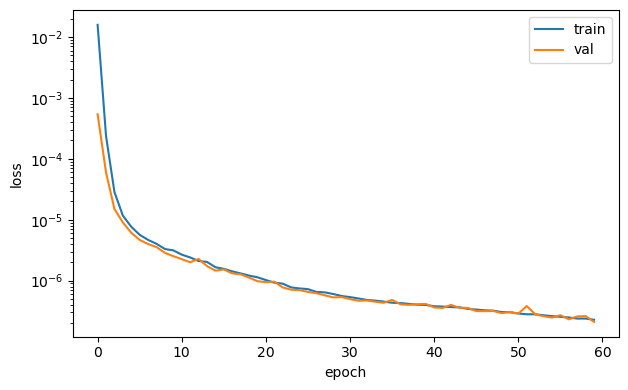

In [9]:
plt.figure(1, (12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('loss')
plt.yscale("log")
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.tight_layout()

### Evaluate the model
Investigate the forecasting capabilities of the model.

In [20]:
def predict_next_k(model, window, k=10):
    """Predict next k steps for the given model and starting sequence """
    x = window[np.newaxis, :, np.newaxis]  # initial input
    y = np.zeros(k)
    for i in range(k):
        [[y[i]]] = model.predict(x, verbose=0)
        # create the new input including the last prediction
        x = np.roll(x, -1, axis=1)  # shift all inputs 1 step to the left
        x[:, -1] = y[i]  # add latest prediction to end
    return y

In [21]:
def plot_prediction(i0=0, k=500):
    """ Predict and plot the next k steps for an input starting at i0 """
    y0 = f[i0: i0 + window_size]  # starting window (input)
    y1 = predict_next_k(model, y0, k)  # predict next k steps

    t0 = t[i0: i0 + window_size]
    t1 = t[i0 + window_size: i0 + window_size + k]

    plt.figure(figsize=(12, 4))
    plt.plot(t, f, label='data')
    plt.plot(t0, y0, color='C1', lw=3, label='prediction')
    plt.plot(t1, y1, color='C1', ls='--')
    plt.xlim(0, 10)
    plt.legend()
    plt.xlabel('$t$')
    plt.ylabel('$f(t)$')

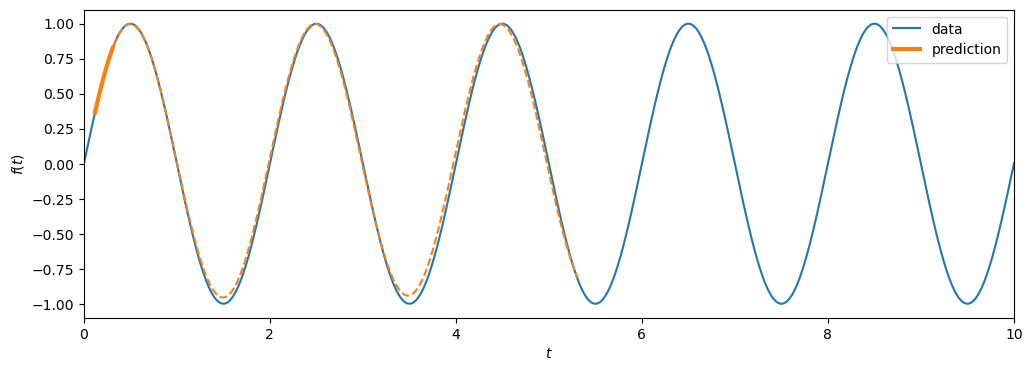

In [22]:
plot_prediction(12)

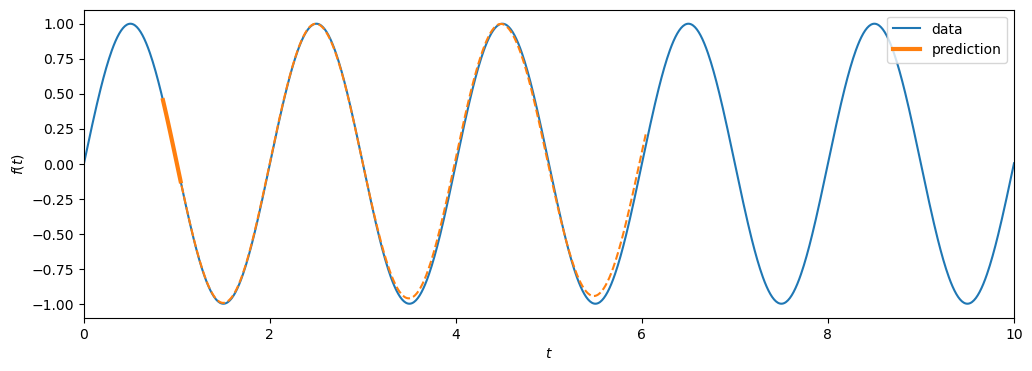

In [23]:
plot_prediction(85)

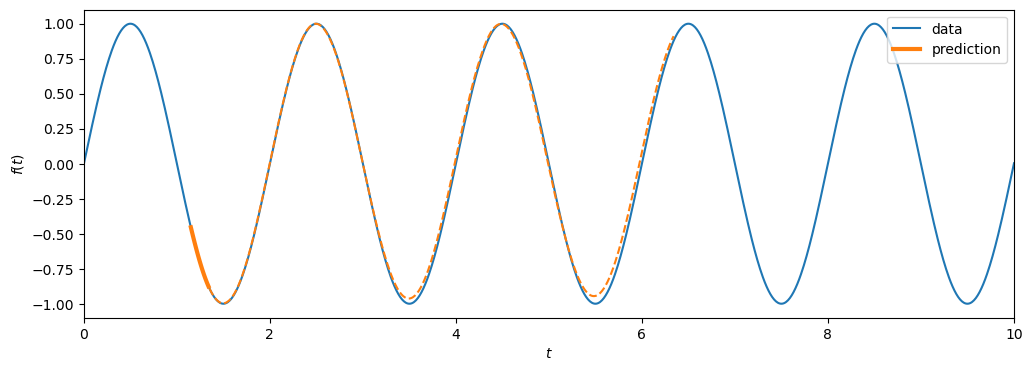

In [24]:
plot_prediction(115)

We see that the model predicts pretty well the sine function. We observe that after some periods the matching starts to be worse, which could be expected as the output is less and less based on the original data.

### Other configurations

We try first with a smaller window size and less LSTM layers.

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
281/281 - 1s - 5ms/step - loss: 0.0444 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 2/60
281/281 - 1s - 3ms/step - loss: 0.0027 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 3/60
281/281 - 1s - 3ms/step - loss: 0.0013 - val_loss: 9.1635e-04 - learning_rate: 0.0010
Epoch 4/60
281/281 - 1s - 3ms/step - loss: 6.5037e-04 - val_loss: 4.3680e-04 - learning_rate: 0.0010
Epoch 5/60
281/281 - 1s - 3ms/step - loss: 3.2154e-04 - val_loss: 2.4010e-04 - learning_rate: 0.0010
Epoch 6/60
281/281 - 1s - 3ms/step - loss: 1.7149e-04 - val_loss: 1.3059e-04 - learning_rate: 0.0010
Epoch 7/60
281/281 - 1s - 3ms/step - loss: 1.0509e-04 - val_loss: 8.0759e-05 - learning_rate: 0.0010
Epoch 8/60
281/281 - 1s - 3ms/step - loss: 7.1188e-05 - val_loss: 5.5614e-05 - learning_rate: 0.0010
Epoch 9/60

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0006700000318232924.
281/281 - 1s - 3ms/step - loss: 4.6983e-05 - val_loss: 3.9436e-05 - learning_rate: 0.0010
Epoch 10/60
281/281 - 1s - 3m

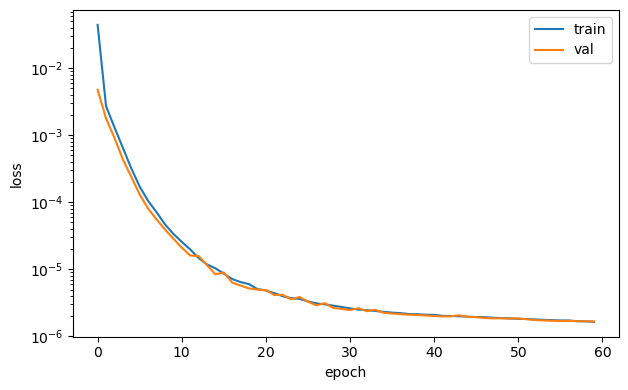

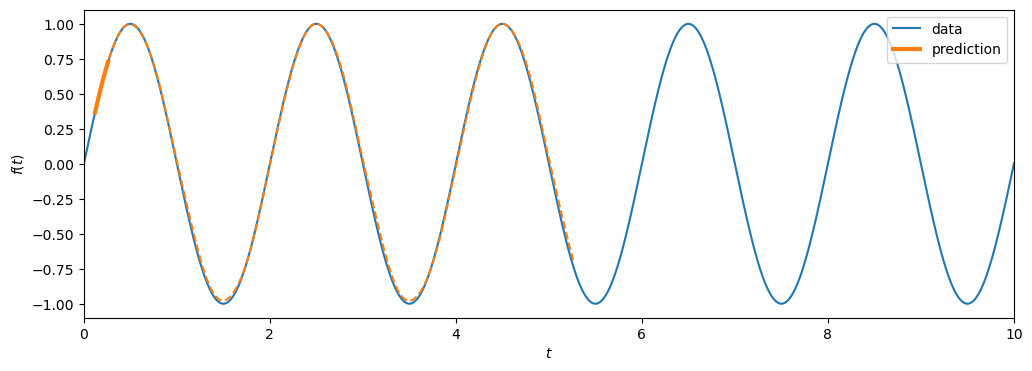

In [27]:
window_size = 15
n_layers = 10

n = N - window_size - 1  # number of possible splits
data = np.stack([f[i: i + window_size + 1] for i in range(n)])

X, y = np.split(data, [-1], axis=1)
X = X[..., np.newaxis]

z0 = layers.Input(shape=[None, 1])
z = layers.LSTM(n_layers)(z0)
z = layers.Dense(1)(z)
model = keras.models.Model(inputs=z0, outputs=z)
print(model.summary())

model.compile(loss='mse', optimizer='adam')

results = model.fit(X, y,
    epochs=60,
    batch_size=32,
    verbose=2,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, verbose=1, min_lr=1E-5),
        keras.callbacks.EarlyStopping(patience=4, verbose=1)])

plt.figure(1, (12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('loss')
plt.yscale("log")
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.tight_layout()

plot_prediction(12)

The different does not seem important, and the computing time was smaller.

Let us try to reduce the complexity even more.

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 5)              │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
281/281 - 1s - 4ms/step - loss: 0.3397 - val_loss: 0.0243 - learning_rate: 0.0010
Epoch 2/60
281/281 - 1s - 2ms/step - loss: 0.0174 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 3/60
281/281 - 1s - 2ms/step - loss: 0.0103 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 4/60
281/281 - 1s - 3ms/step - loss: 0.0065 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 5/60
281/281 - 1s - 2ms/step - loss: 0.0040 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 6/60
281/281 - 1s - 2ms/step - loss: 0.0022 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 7/60
281/281 - 1s - 2ms/step - loss: 0.0013 - val_loss: 9.7301e-04 - learning_rate: 0.0010
Epoch 8/60
281/281 - 1s - 2ms/step - loss: 8.2005e-04 - val_loss: 6.9986e-04 - learning_rate: 0.0010
Epoch 9/60
281/281 - 1s - 2ms/step - loss: 6.3311e-04 - val_loss: 5.6351e-04 - learning_rate: 0.0010
Epoch 10/60
281/281 - 1s - 2ms/step - loss: 5.1951e-04 - val_loss: 4.6696e-04 - learning_rate: 0.0010
Epoch 11/60
281/281 - 1s - 2ms/step 

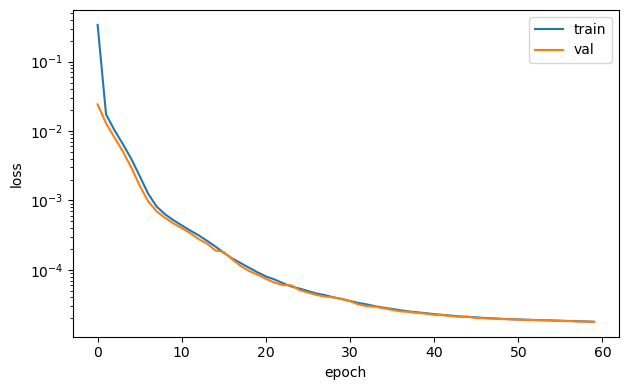

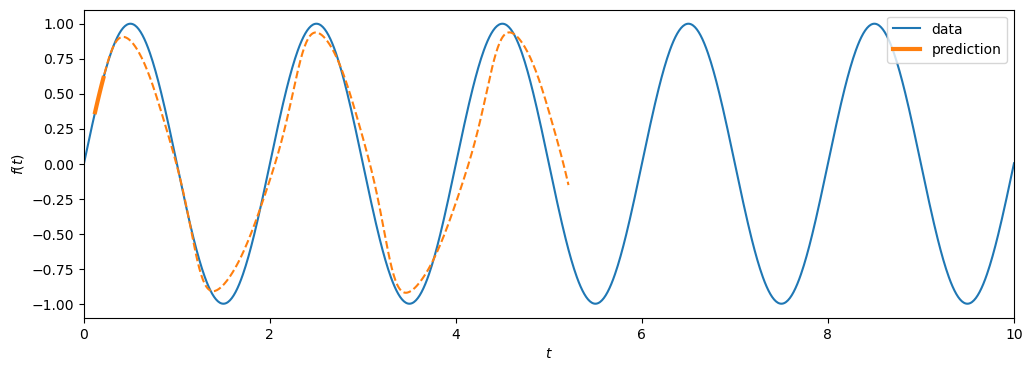

In [28]:
window_size = 10
n_layers = 5

n = N - window_size - 1  # number of possible splits
data = np.stack([f[i: i + window_size + 1] for i in range(n)])

X, y = np.split(data, [-1], axis=1)
X = X[..., np.newaxis]

z0 = layers.Input(shape=[None, 1])
z = layers.LSTM(n_layers)(z0)
z = layers.Dense(1)(z)
model = keras.models.Model(inputs=z0, outputs=z)
print(model.summary())

model.compile(loss='mse', optimizer='adam')

results = model.fit(X, y,
    epochs=60,
    batch_size=32,
    verbose=2,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, verbose=1, min_lr=1E-5),
        keras.callbacks.EarlyStopping(patience=4, verbose=1)])

plt.figure(1, (12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('loss')
plt.yscale("log")
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.tight_layout()

plot_prediction(12)

The performance is much worse now.

Let us keep this window size, but increase the number of layers again.

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
281/281 - 1s - 4ms/step - loss: 0.0718 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 2/60
281/281 - 1s - 2ms/step - loss: 0.0096 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 3/60
281/281 - 1s - 2ms/step - loss: 0.0041 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 4/60
281/281 - 1s - 2ms/step - loss: 0.0011 - val_loss: 5.3347e-04 - learning_rate: 0.0010
Epoch 5/60
281/281 - 1s - 2ms/step - loss: 3.4055e-04 - val_loss: 2.6314e-04 - learning_rate: 0.0010
Epoch 6/60
281/281 - 1s - 2ms/step - loss: 1.8743e-04 - val_loss: 1.5644e-04 - learning_rate: 0.0010
Epoch 7/60
281/281 - 1s - 2ms/step - loss: 1.1894e-04 - val_loss: 1.0950e-04 - learning_rate: 0.0010
Epoch 8/60
281/281 - 1s - 2ms/step - loss: 7.8033e-05 - val_loss: 6.7729e-05 - learning_rate: 0.0010
Epoch 9/60
281/281 - 1s - 2ms/step - loss: 5.0454e-05 - val_loss: 4.3070e-05 - learning_rate: 0.0010
Epoch 10/60
281/281 - 0s - 2ms/step - loss: 3.2719e-05 - val_loss: 2.1976e-05 - learning_rate: 0.0010
Epoch 11/60


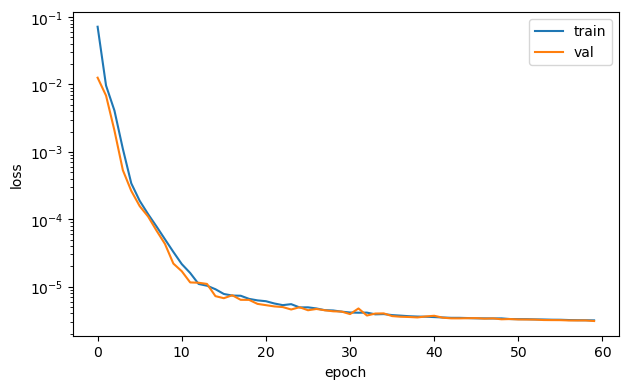

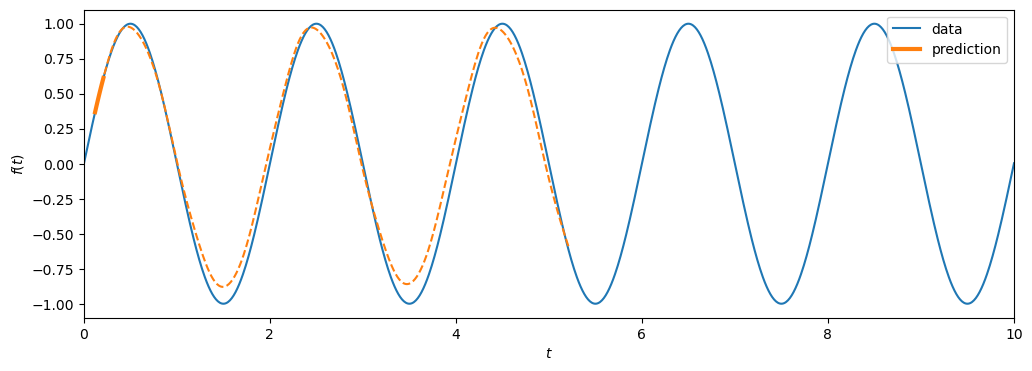

In [30]:
window_size = 10
n_layers = 10

n = N - window_size - 1  # number of possible splits
data = np.stack([f[i: i + window_size + 1] for i in range(n)])

X, y = np.split(data, [-1], axis=1)
X = X[..., np.newaxis]

z0 = layers.Input(shape=[None, 1])
z = layers.LSTM(n_layers)(z0)
z = layers.Dense(1)(z)
model = keras.models.Model(inputs=z0, outputs=z)
print(model.summary())

model.compile(loss='mse', optimizer='adam')

results = model.fit(X, y,
    epochs=60,
    batch_size=32,
    verbose=2,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, verbose=1, min_lr=1E-5),
        keras.callbacks.EarlyStopping(patience=4, verbose=1)])

plt.figure(1, (12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('loss')
plt.yscale("log")
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.tight_layout()

plot_prediction(12)

The performance is better, but still not really good.

We try the last set-up.

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 5)              │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/60
281/281 - 1s - 5ms/step - loss: 0.1952 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 2/60
281/281 - 1s - 3ms/step - loss: 0.0180 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 3/60
281/281 - 1s - 3ms/step - loss: 0.0044 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 4/60
281/281 - 1s - 3ms/step - loss: 0.0016 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/60
281/281 - 1s - 2ms/step - loss: 0.0010 - val_loss: 8.3212e-04 - learning_rate: 0.0010
Epoch 6/60
281/281 - 1s - 2ms/step - loss: 7.0369e-04 - val_loss: 5.9609e-04 - learning_rate: 0.0010
Epoch 7/60
281/281 - 1s - 2ms/step - loss: 5.0277e-04 - val_loss: 4.1851e-04 - learning_rate: 0.0010
Epoch 8/60
281/281 - 1s - 2ms/step - loss: 3.6545e-04 - val_loss: 3.1216e-04 - learning_rate: 0.0010
Epoch 9/60
281/281 - 1s - 2ms/step - loss: 2.6694e-04 - val_loss: 2.1972e-04 - learning_rate: 0.0010
Epoch 10/60
281/281 - 1s - 2ms/step - loss: 1.9092e-04 - val_loss: 1.5302e-04 - learning_rate: 0.0010
Epoch 11/60
281/281 

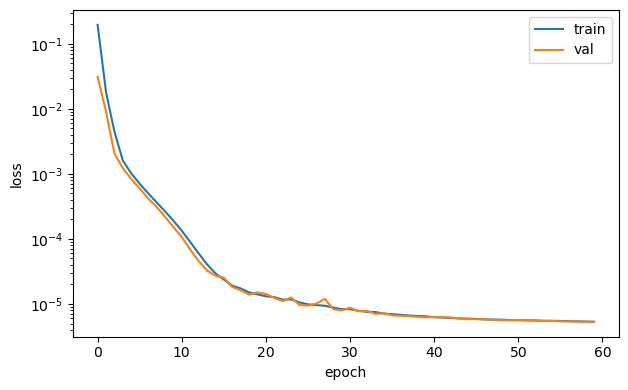

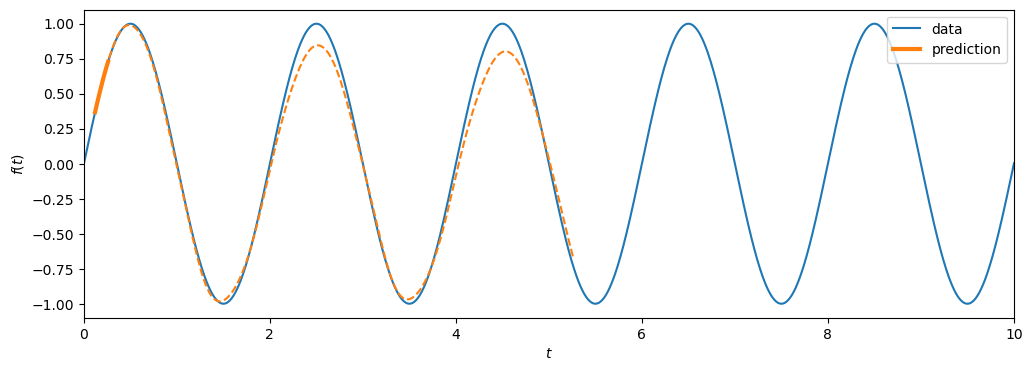

In [31]:
window_size = 15
n_layers = 5

n = N - window_size - 1  # number of possible splits
data = np.stack([f[i: i + window_size + 1] for i in range(n)])

X, y = np.split(data, [-1], axis=1)
X = X[..., np.newaxis]

z0 = layers.Input(shape=[None, 1])
z = layers.LSTM(n_layers)(z0)
z = layers.Dense(1)(z)
model = keras.models.Model(inputs=z0, outputs=z)
print(model.summary())

model.compile(loss='mse', optimizer='adam')

results = model.fit(X, y,
    epochs=60,
    batch_size=32,
    verbose=2,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, verbose=1, min_lr=1E-5),
        keras.callbacks.EarlyStopping(patience=4, verbose=1)])

plt.figure(1, (12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('loss')
plt.yscale("log")
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.tight_layout()

plot_prediction(12)

The result is again not very good.

As a summary, we had:
| window size | number of layers | performance |
|-------------|------------------|-------------|
| 20          | 16               | good        |
| 15          | 10               | good        |
| 10          | 5                | very bad    |
| 10          | 10               | bad         |
| 15          | 5                | bad         |

Both the number of layers and the window size are important. 

Note that the code before created more batches if the window size was smaller (fixed total number of points). This means the models with smaller window size are more trained in our analysis. However, it is not very important since the loss is not decreasing much at the end of the training.